# Dependencies

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
# Combine training and test data for easier manipulation (seperate later)

training = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

training ['train_test'] = 1
test ['train_test'] = 0
test ['Survived'] = np.nan
all_data = pd.concat([training, test])

%matplotlib inline
all_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='object')

# Determine what data we're working with (e.g. Columns, Rows, dtypes) by checking info and describe

In [3]:
# Using .info() loads the dataset's structure including names of columns, datatypes, and non null data present
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [4]:
# Using .describe() shows statistical distributions such mean, median, and standard deviation
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.0


In [5]:
# .describe() for columns lists each column name
training.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'train_test'],
      dtype='object')

In [6]:
# Check for missing/null values
training.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
train_test       0
dtype: int64

In [7]:
# Categorize variables under numerical or categorical (only for those that apply)
df_num = training[['Age', 'SibSp', 'Parch', 'Fare']]
df_cat = training[['Pclass', 'Sex', 'Survived', 'Ticket', 'Cabin', 'Embarked']]

# Check distributions and general trends of each variable through Feature Engineering

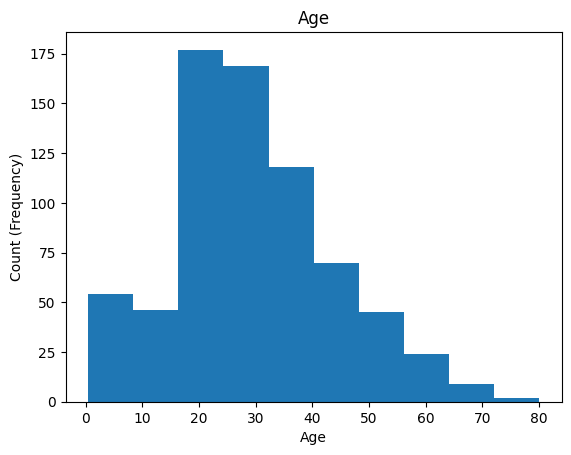

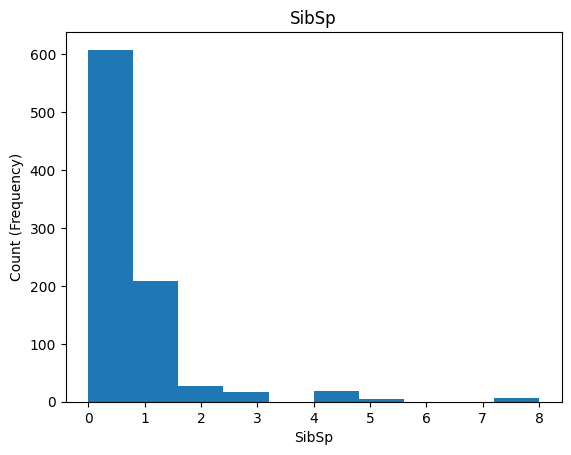

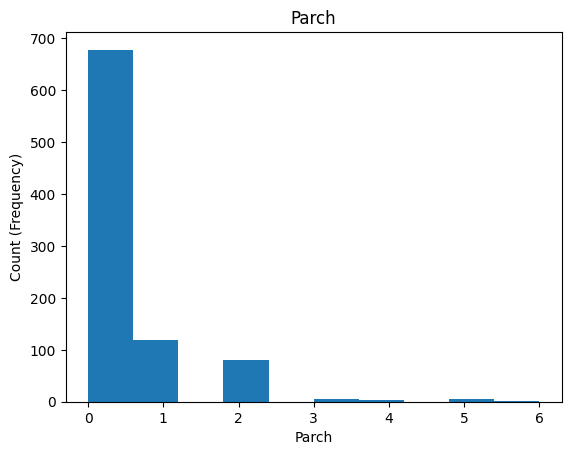

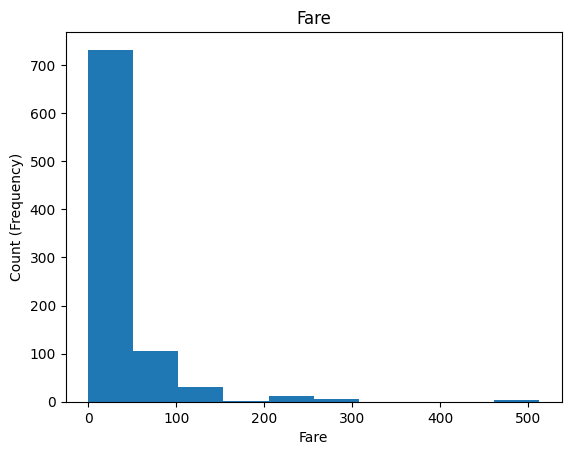

In [8]:
# For loop for checking all datapoints
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.xlabel(i)
    plt.ylabel('Count (Frequency)')
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

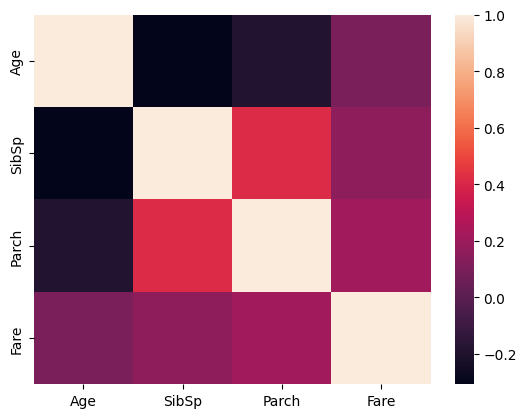

In [9]:
# Checks correlations
print(df_num.corr())
sns.heatmap(df_num.corr())

In [10]:
# Compare variables with Survival to check for trends
pd.pivot_table(training, index = 'Survived', values = ['Age', 'SibSp', 'Parch', 'Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


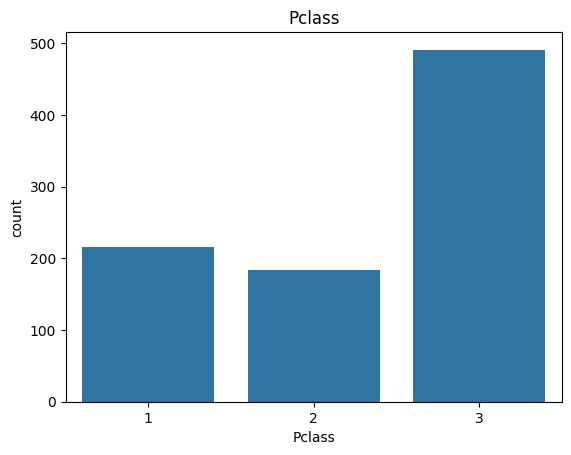

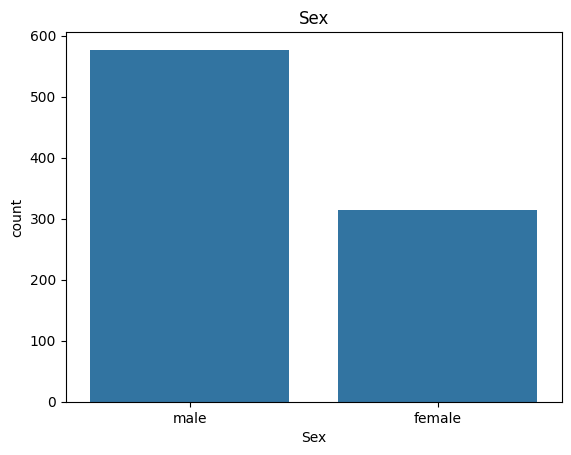

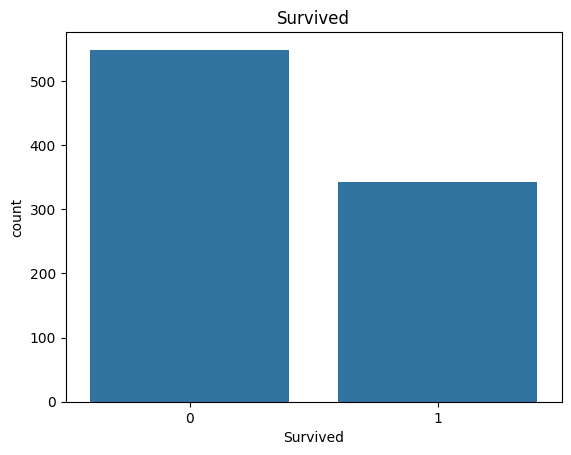

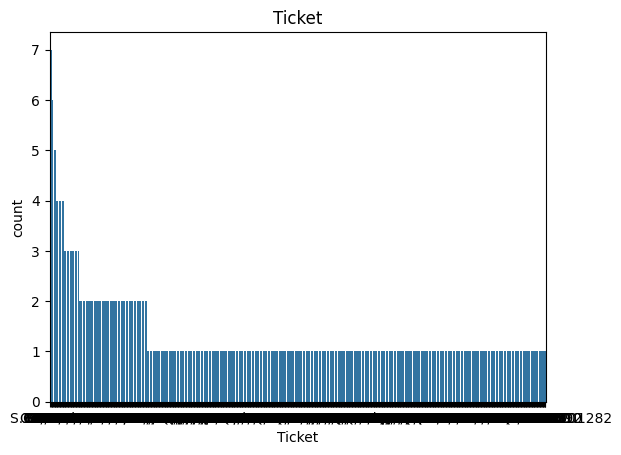

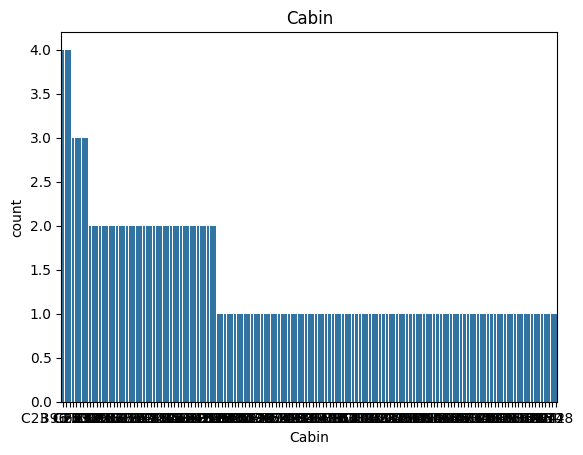

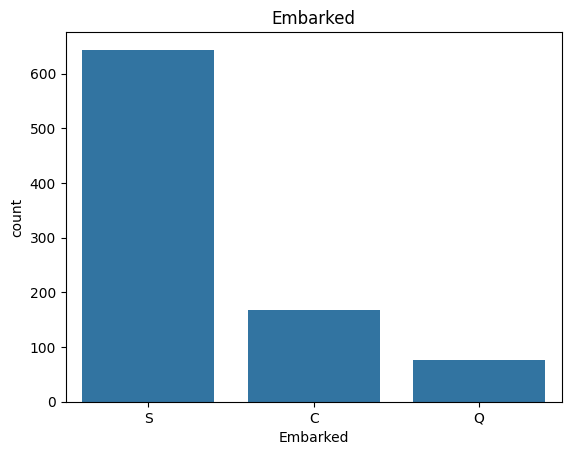

In [11]:
for i in df_cat.columns:
    sns.barplot(x = df_cat[i].value_counts().index, y = df_cat[i].value_counts()).set_title(i)
    plt.show()

In [12]:
print(pd.pivot_table(training, index = 'Survived', columns = 'Pclass', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(training, index = 'Survived', columns = 'Sex', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(training, index = 'Survived', columns = 'Embarked', values='Ticket', aggfunc='count'))
print()

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Sex       female  male
Survived              
0             81   468
1            233   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217



# Feature Engineering on Cabin variable

In [13]:
# Identified the reserved cabins for each ticket
df_cat.Cabin
training['cabin_multiple'] = training.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
training['cabin_multiple'].value_counts()

cabin_multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

In [14]:
# Checks correlation between survival and recorded cabins
pd.pivot_table(training, index = 'Survived', columns = 'cabin_multiple', values = 'Ticket' ,aggfunc ='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [15]:
# Individual cabin names like C45 are stripped so that only the letters are shown indicating what floor they were on
training['cabin_adv'] = training.Cabin.apply(lambda x: 'n' if pd.isna(x) else str(x)[0])

In [16]:
# Prints a list of all cabin categories and compares each to survival of passengers
print(training.cabin_adv.value_counts())
pd.pivot_table(training,index='Survived',columns='cabin_adv', values = 'Name', aggfunc='count')

cabin_adv
n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


# Feature Engineering on Tickets variable

In [17]:
# Seperating tickets by type (pure numeric, alphanumeric prefixes, and pure alphabetical prefixes) (e.g., 11037, A3 83942, UD 92415)
training['numeric_ticket'] = training.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
training['ticket_letters'] = training.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1]) >0 else 0)

In [18]:
# Lists out the count of numeric against non-numeric tickets
training['numeric_ticket'].value_counts()

numeric_ticket
1    661
0    230
Name: count, dtype: int64

In [19]:
# Lists out the counts of alphanumeric and pure alphabetical prefixed tickets
pd.set_option("display.max_rows", None)
training['ticket_letters'].value_counts()

ticket_letters
0            665
pc            60
ca            41
a5            21
stono2        18
sotonoq       15
scparis       11
wc            10
a4             7
soc            6
c              5
fcc            5
pp             3
wep            3
sopp           3
ppp            2
sotono2        2
scah           2
swpp           2
sp             1
sca4           1
scow           1
fa             1
sop            1
sc             1
scahbasle      1
as             1
fc             1
casoton        1
Name: count, dtype: int64

In [20]:
# Compares numeric tickets against survival of passengers
pd.pivot_table(training,index='Survived',columns='numeric_ticket', values = 'Ticket', aggfunc='count')

numeric_ticket,0,1
Survived,,
0,142,407
1,88,254


In [21]:
# Compares alphanumeric and numeric tickets against survival of passengers
pd.pivot_table(training,index='Survived',columns='ticket_letters', values = 'Ticket', aggfunc='count')

ticket_letters,0,a4,a5,as,c,ca,casoton,fa,fc,fcc,...,soc,sop,sopp,sotono2,sotonoq,sp,stono2,swpp,wc,wep
Survived,,,,,,,,,,,,,,,,,,,,,
0,410.0,7.0,19.0,1.0,3.0,27.0,1.0,1.0,1.0,1.0,...,5.0,1.0,3.0,2.0,13.0,1.0,10.0,NaN,9.0,2.0
1,255.0,NaN,2.0,NaN,2.0,14.0,NaN,NaN,NaN,4.0,...,1.0,NaN,NaN,NaN,2.0,NaN,8.0,2.0,1.0,1.0


# Feature Engineering on passenger titles as a variable

In [22]:
# Seperates titles from passenger names, then returns the top 50 names for checking
training.Name.head(50)
training['name_title'] = training.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

In [23]:
# Lists the count of all titles 
training['name_title'].value_counts()

name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [24]:
# Checks correlation between titles and survival
pd.pivot_table(training,index='Survived',columns='name_title', values = 'Name', aggfunc='count')

name_title,Capt,Col,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess
Survived,,,,,,,,,,,,,,,,,
0,1.0,1.0,1.0,4.0,1.0,NaN,1.0,17.0,55.0,NaN,NaN,436.0,26.0,NaN,6.0,NaN,NaN
1,NaN,1.0,NaN,3.0,NaN,1.0,1.0,23.0,127.0,2.0,1.0,81.0,99.0,1.0,NaN,1.0,1.0


# Combines families under one group variable

In [25]:
# Combines Sibling/Spouse, Parent/Children, and the individual owning the ticket into one new variable 
training['family_size'] = training.SibSp + training.Parch + 1

In [26]:
# Lists down the counts of family sizes
training['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [27]:
# Checks correlation between family sizes and survival
pd.pivot_table(training,index='Survived',columns='family_size', values = 'Name', aggfunc='count')

family_size,1,2,3,4,5,6,7,8,11
Survived,,,,,,,,,
0,374.0,72.0,43.0,8.0,12.0,19.0,8.0,6.0,7.0
1,163.0,89.0,59.0,21.0,3.0,3.0,4.0,NaN,NaN


# Normalizes the skew

In [28]:
# Log transforms fares to prevent a skewed chart
training['norm_fare'] = np.log(training.Fare + 1)

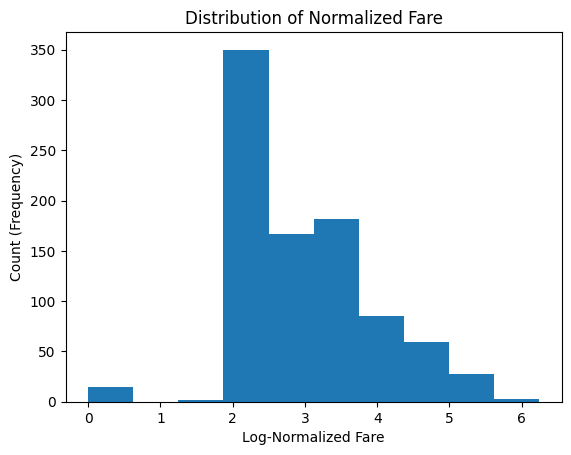

In [29]:
plt.hist(training.norm_fare)
plt.xlabel('Log-Normalized Fare')
plt.ylabel('Count (Frequency)')
plt.title('Distribution of Normalized Fare')
plt.show()

In [30]:
# Conversion of log(2), replace 2 with any other number to check dollar equivalent of the log transform
(np.exp(2) - 1)

np.float64(6.38905609893065)

In [31]:
# Correlates average fare of survivors
pd.pivot_table(training, index='Survived', values='Fare', aggfunc='mean')

,Fare
Survived,
0,22.117887
1,48.395408


# Data Pre-Processing

# Drop null 'Embarked' values

In [32]:
# Drops null values in 'Embarked'
training = training.dropna(subset=['Embarked'])

In [33]:
# Checks for the null values
training['Embarked'].isnull().sum()

np.int64(0)

# Fill the missing value in test dataset

In [34]:
# Confirm missing data in test dataset
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
train_test       0
Survived       418
dtype: int64

In [35]:
# Fill the single missing value in Fare with the median
test['Fare'] = test['Fare'].fillna(test['Fare'].median)
test['Fare'].isnull().sum()

np.int64(0)

In [36]:
# Create all categorical variables that we did above for both training and test sets 
all_data['cabin_multiple'] = all_data.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
all_data['cabin_adv'] = all_data.Cabin.apply(lambda x: 'n' if pd.isna(x) else str(x)[0])
all_data['numeric_ticket'] = all_data.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
all_data['ticket_letters'] = all_data.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1]) >0 else 0)
all_data['name_title'] = all_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
all_data['family_size'] = all_data.SibSp + all_data.Parch + 1

# Seperate name titles from names
training['name_title'] = training.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# Impute nulls for continuous data 
# Fills NaN values in Age column with a rounded up median
age_fill_map = training.groupby(['name_title', 'Pclass'])['Age'].median()
all_data['Age'] = all_data.apply(
    lambda row: age_fill_map.get((row['name_title'], row['Pclass']), training['Age'].median())
    if pd.isna(row['Age']) else row['Age'], axis=1
)

# Impute Fare with training median
all_data.Fare = all_data.Fare.fillna(training.Fare.median())

# Drop null 'embarked' rows. Only 2 instances of this in training and 0 in test 
all_data.dropna(subset=['Embarked'], inplace=True)

# Log-normalize Fare
all_data['norm_fare'] = np.log(all_data.Fare + 1)

# Converted fare to category for pd.get_dummies()
all_data.Pclass = all_data.Pclass.astype(str)

# Created dummy variables from categories
all_dummies = pd.get_dummies(all_data[['Pclass','Sex','Age','SibSp','Parch','family_size',
                                        'norm_fare','Embarked','cabin_adv','cabin_multiple',
                                        'numeric_ticket','name_title','train_test']])
# Split to train test again
X_train = all_dummies[all_dummies.train_test == 1].drop(['train_test'], axis =1)
X_test = all_dummies[all_dummies.train_test == 0].drop(['train_test'], axis =1)

# Filters all_data to only show survival status in training data
y_train = all_data[all_data.train_test==1].Survived
y_train.shape

(889,)

# Scaling

In [37]:
# Measures different variables under the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building & Evaluation

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

model_scores = {}

In [39]:
# Performs a 5-fold cross validation of logistic regression algorithm

# Uses unscaled data
lr = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
lr_mean = cv_scores.mean()
print(cv_scores)
print(f"Unscaled Mean Accuracy: {lr_mean:.2%}") 

# Uses scaled data
lr = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)
slr_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {slr_mean:.2%}") # This is our baseline accuracy (since its the first one we tested) as well as our algorithm's accuracy

model_scores['lr'] = slr_mean

[0.8258427  0.82022472 0.80337079 0.83146067 0.86440678]
Unscaled Mean Accuracy: 82.91%
[0.81460674 0.81460674 0.79213483 0.82022472 0.86440678]
Scaled Mean Accuracy: 82.12%


In [40]:
# Decision Tree Algorithm

# Uses unscaled data
dt = tree.DecisionTreeClassifier(random_state = 42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
dt_mean = cv_scores.mean()
print(cv_scores)
print(f"Unscaled Mean Accuracy: {dt_mean:.2%}") 

# Uses scaled data
dt = tree.DecisionTreeClassifier(random_state = 42)
cv_scores = cross_val_score(dt, X_train_scaled, y_train, cv=5)
sdt_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {sdt_mean:.2%}")

model_scores['dt'] = sdt_mean

[0.75842697 0.78089888 0.84269663 0.76404494 0.75706215]
Unscaled Mean Accuracy: 78.06%
[0.76966292 0.78089888 0.83707865 0.76404494 0.76271186]
Scaled Mean Accuracy: 78.29%


In [41]:
# K-Nearest Neighbors Classifier algorithm

# Uses unscaled data
knn = KNeighborsClassifier()
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)
knn_mean = cv_scores.mean()
print(cv_scores)
print(f"Unscaled Mean Accuracy: {knn_mean:.2%}") 

# Uses scaled data
knn = KNeighborsClassifier()
cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
sknn_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {sknn_mean:.2%}")

model_scores['knn'] = sknn_mean

[0.80337079 0.78089888 0.78089888 0.80898876 0.84745763]
Unscaled Mean Accuracy: 80.43%
[0.79213483 0.74719101 0.8258427  0.79775281 0.83050847]
Scaled Mean Accuracy: 79.87%


In [42]:
# Random Forest Classifier Algorithm

# Uses unscaled data
rf = RandomForestClassifier(random_state = 42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
rf_mean = cv_scores.mean()
print(cv_scores)
print(f"Unscaled Mean Accuracy: {rf_mean:.2%}") 

# Uses scaled data
rf = RandomForestClassifier(random_state = 42)
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5)
srf_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {srf_mean:.2%}")

model_scores['rf'] = srf_mean

[0.81460674 0.78089888 0.85393258 0.76404494 0.82485876]
Unscaled Mean Accuracy: 80.77%
[0.82022472 0.78089888 0.84831461 0.76966292 0.82485876]
Scaled Mean Accuracy: 80.88%


In [43]:
# Support Vector Classifier

# Uses scaled data
svc = SVC(probability = True)
cv_scores = cross_val_score(svc, X_train_scaled, y_train, cv=5)
svc_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {svc_mean:.2%}")

model_scores['svc'] = svc_mean

[0.80337079 0.80337079 0.81460674 0.79213483 0.85875706]
Scaled Mean Accuracy: 81.44%


In [44]:
# Xtreme Gradient Boosting

# Uses scaled data
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state =1)
cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5)
xgb_mean = cv_scores.mean()
print(cv_scores)
print(f"Scaled Mean Accuracy: {xgb_mean:.2%}")

model_scores['xgb'] = xgb_mean

[0.83146067 0.80898876 0.83707865 0.79213483 0.82485876]
Scaled Mean Accuracy: 81.89%


In [45]:
#Voting classifier takes all of the inputs and averages the results. For a "hard" voting classifier each classifier gets 1 vote "yes" or "no" and the result is just a popular vote. For this, you generally want odd numbers
#A "soft" classifier averages the confidence of each of the models. If a the average confidence is > 50% that it is a 1 it will be counted as such
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(estimators = [('lr',lr),('knn',knn),('rf',rf),('svc',svc),('xgb',xgb)], voting = 'soft') 

In [46]:
# All Models mean accuracy
cv = cross_val_score(voting_clf,X_train_scaled,y_train,cv=5)
print(cv)
mean = cv.mean()
print(f"Scaled Mean Accuracy: {mean:.2%}")

[0.80898876 0.80337079 0.83146067 0.79775281 0.85310734]
Scaled Mean Accuracy: 81.89%


In [47]:
# Lists out individual accuracy scores in descending order
results_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x:.2%}")
results_df

,Model,Accuracy
0,lr,82.12%
1,xgb,81.89%
2,svc,81.44%
3,rf,80.88%
4,knn,79.87%
5,dt,78.29%


In [48]:
# Baseline analysis submission

voting_clf.fit(X_train_scaled,y_train)
y_hat_base_vc = voting_clf.predict(X_test_scaled).astype(int)
basic_submission = {'PassengerId': test.PassengerId, 'Survived': y_hat_base_vc}
base_submission = pd.DataFrame(data=basic_submission)
base_submission.to_csv('base_submission.csv', index=False)

# Model Tuning

In [49]:
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 

In [50]:
# Reusable performance report function
def clf_performance(classifier, model_name):
    print(model_name)
    print('Best Score: ' + str(classifier.best_score_))
    print('Best Parameters: ' + str(classifier.best_params_))

In [51]:
# Logistic Regression grid search
lr = LogisticRegression()
param_grid = {'max_iter' : [2000],
              'penalty' : ['l1', 'l2'],
              'C' : np.logspace(-4, 4, 20),
              'solver' : ['liblinear']}

clf_lr = GridSearchCV(lr, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_lr = clf_lr.fit(X_train_scaled,y_train)
clf_performance(best_clf_lr,'Logistic Regression')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression
Best Score: 0.8279375357074843
Best Parameters: {'C': np.float64(0.08858667904100823), 'max_iter': 2000, 'penalty': 'l2', 'solver': 'liblinear'}


In [52]:
# K Number Neighbors grid search
knn = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9],
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto', 'ball_tree','kd_tree'],
              'p' : [1,2]}
clf_knn = GridSearchCV(knn, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_knn = clf_knn.fit(X_train_scaled,y_train)
clf_performance(best_clf_knn,'KNN')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN
Best Score: 0.815552593156859
Best Parameters: {'algorithm': 'auto', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}


In [53]:
""""First use a randomized search to narrow down the paramters for the model, then take 
the best model from this and conduct a more granular search """

# This code block will be a one time use

""""rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [100,500,1000], 
                'bootstrap': [True,False],
                'max_depth': [3,5,10,20,50,75,100,None],
                'max_features': ['log2','sqrt'],
                'min_samples_leaf': [1,2,4,10],
                'min_samples_split': [2,5,10]}
                                  
clf_rf_rnd = RandomizedSearchCV(rf, param_distributions = param_grid, n_iter = 100, cv = 5, verbose = True, n_jobs = -1)
best_clf_rf_rnd = clf_rf_rnd.fit(X_train_scaled,y_train)
clf_performance(best_clf_rf_rnd,'Random Forest')
"""
# The results here will be the range we'll use for the grid search

'"rf = RandomForestClassifier(random_state = 1)\nparam_grid =  {\'n_estimators\': [100,500,1000], \n                \'bootstrap\': [True,False],\n                \'max_depth\': [3,5,10,20,50,75,100,None],\n                \'max_features\': [\'log2\',\'sqrt\'],\n                \'min_samples_leaf\': [1,2,4,10],\n                \'min_samples_split\': [2,5,10]}\n                                  \nclf_rf_rnd = RandomizedSearchCV(rf, param_distributions = param_grid, n_iter = 100, cv = 5, verbose = True, n_jobs = -1)\nbest_clf_rf_rnd = clf_rf_rnd.fit(X_train_scaled,y_train)\nclf_performance(best_clf_rf_rnd,\'Random Forest\')\n'

In [54]:
# Actual Grid Search to find the best hyperparameters for Random Forest model

rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [80, 100, 150],
               'criterion':['gini','entropy'],
               'bootstrap': [False],
               'max_depth': [70, 80, 90, None],
               'max_features': ['sqrt'],
               'min_samples_leaf': [1,2,3],
               'min_samples_split': [8, 10, 15]}
                                  
clf_rf = GridSearchCV(rf, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_rf = clf_rf.fit(X_train_scaled,y_train)
clf_performance(best_clf_rf,'Random Forest')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest
Best Score: 0.8380371992636324
Best Parameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 70, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 80}


<Axes: >

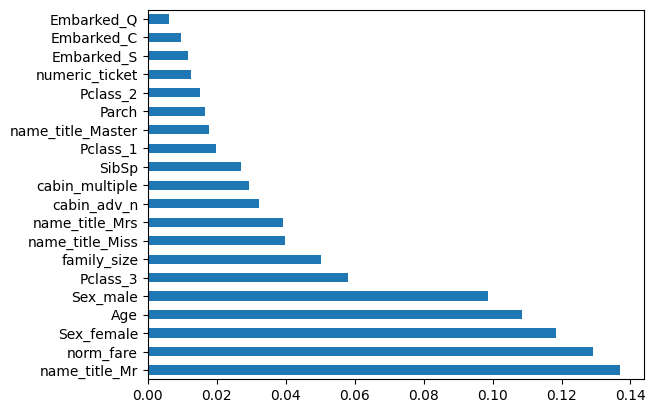

In [55]:
best_rf = best_clf_rf.best_estimator_.fit(X_train_scaled,y_train)
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(20).plot(kind='barh')

In [56]:
""""First use a randomized search to narrow down the paramters for the model, then take 
the best model from this and conduct a more granular search """

# This code block will be a one time use
""""
xgb = XGBClassifier(random_state = 1)

param_grid = {
    'n_estimators': [20, 50, 100, 250, 500, 1000],
    'colsample_bytree': [0.2, 0.5, 0.7, 0.8, 1],
    'max_depth': [2, 5, 10, 15, 20, 25],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 1.5, 2],
    'subsample': [0.5,0.6,0.7, 0.8, 0.9],
    'learning_rate':[.01,0.1,0.2,0.3,0.5, 0.7, 0.9],
    'gamma':[0,.01,.1,1,10],
    'min_child_weight':[0,.01,0.1,1,10],
    'sampling_method': ['uniform']
}

clf_xgb_rnd = RandomizedSearchCV(xgb, param_distributions = param_grid, n_iter = 1000, cv = 5, verbose = True, n_jobs = -1)
best_clf_xgb_rnd = clf_xgb_rnd.fit(X_train_scaled,y_train)
clf_performance(best_clf_xgb_rnd,'XGB')
"""
# The results here will be the range we'll use for the grid search

'"\nxgb = XGBClassifier(random_state = 1)\n\nparam_grid = {\n    \'n_estimators\': [20, 50, 100, 250, 500, 1000],\n    \'colsample_bytree\': [0.2, 0.5, 0.7, 0.8, 1],\n    \'max_depth\': [2, 5, 10, 15, 20, 25],\n    \'reg_alpha\': [0, 0.5, 1],\n    \'reg_lambda\': [1, 1.5, 2],\n    \'subsample\': [0.5,0.6,0.7, 0.8, 0.9],\n    \'learning_rate\':[.01,0.1,0.2,0.3,0.5, 0.7, 0.9],\n    \'gamma\':[0,.01,.1,1,10],\n    \'min_child_weight\':[0,.01,0.1,1,10],\n    \'sampling_method\': [\'uniform\']\n}\n\nclf_xgb_rnd = RandomizedSearchCV(xgb, param_distributions = param_grid, n_iter = 1000, cv = 5, verbose = True, n_jobs = -1)\nbest_clf_xgb_rnd = clf_xgb_rnd.fit(X_train_scaled,y_train)\nclf_performance(best_clf_xgb_rnd,\'XGB\')\n'

In [57]:
# Actual Grid Search to find the best hyperparameters for Xtreme Gradient Boosting model

xgb = XGBClassifier(random_state = 1)

param_grid = {
    'n_estimators': [100, 250, 500],
    'colsample_bytree': [0.7, 0.85, 1],
    'max_depth': [2, 3, 4],
    'reg_alpha': [1],
    'reg_lambda': [1, 2, 5],
    'subsample': [0.45, 0.5, 0.55],
    'learning_rate':[0.1, 0.3, 0.5],
    'gamma':[0.001, 0.01, 0.1],
    'min_child_weight':[0.5, 1, 2],
    'sampling_method': ['uniform']
}

clf_xgb = GridSearchCV(xgb, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_xgb = clf_xgb.fit(X_train_scaled,y_train)
clf_performance(best_clf_xgb,'XGB')

Fitting 5 folds for each of 6561 candidates, totalling 32805 fits
XGB
Best Score: 0.8526693328254936
Best Parameters: {'colsample_bytree': 0.85, 'gamma': 0.1, 'learning_rate': 0.3, 'max_depth': 2, 'min_child_weight': 0.5, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 5, 'sampling_method': 'uniform', 'subsample': 0.55}


In [58]:
print(f"Logistic Regression: {best_clf_lr.best_score_:.2%}")
print(f"XGBoost:             {best_clf_xgb.best_score_:.2%}")
print(f"Random Forest:       {best_clf_rf.best_score_:.2%}")

Logistic Regression: 82.79%
XGBoost:             85.27%
Random Forest:       83.80%


In [59]:
y_hat_xgb = best_clf_xgb.best_estimator_.predict(X_test_scaled).astype(int)
xgb_submission = {'PassengerId': test.PassengerId, 'Survived': y_hat_xgb}
submission_xgb = pd.DataFrame(data=xgb_submission)
submission_xgb.to_csv('xgb_submission3.csv', index=False)